# Vector Space Model — Embedding & Semantic Search

> **Đồ án cuối kỳ NLP**

## Mục lục
1. [Giới thiệu Dataset & Mô hình](#1-giới-thiệu-dataset--mô-hình)
2. [EDA — Phân tích khám phá dữ liệu](#2-eda--phân-tích-khám-phá-dữ-liệu)
3. [Model — Xây dựng & đánh giá mô hình](#3-model--xây-dựng--đánh-giá-mô-hình)
4. [Tổng hợp & Định hướng](#4-tổng-hợp--định-hướng)

---

_(Sườn bài — nội dung chi tiết sẽ điền sau)_

# 1. Giới thiệu Dataset & Mô hình

## 1.1. Tổng quan Dataset
- Tên dataset:
- Nguồn / cách thu thập:
- Kích thước (số mẫu, số cột):
- Mô tả các trường dữ liệu:
- Bài toán hướng tới (semantic search / retrieval / similarity):

## 1.2. Giới thiệu các mô hình

### 1.2.1. E5 Embedding — `intfloat/e5-small-v2`
- Kiến trúc & ý tưởng chính:
- Đặc điểm (prefix `query:` / `passage:`, kích thước embedding...):
- Ưu / nhược điểm:

### 1.2.2. Sentence Transformers — `sentence-transformers/all-MiniLM-L6-v2`
- Kiến trúc & ý tưởng chính:
- Đặc điểm (kích thước embedding, tốc độ...):
- Ưu / nhược điểm:

### 1.2.3. So sánh nhanh 2 mô hình
| Tiêu chí | e5-small-v2 | all-MiniLM-L6-v2 |
|---|---|---|
| Số chiều embedding |  |  |
| Kích thước mô hình |  |  |
| Yêu cầu prefix |  |  |
| Ghi chú |  |  |

# 2. EDA — Phân tích khám phá dữ liệu

## 2.1. Tải & quan sát dữ liệu
- Đọc dữ liệu, xem `head()`, `info()`, `describe()`

## 2.2. Kiểm tra chất lượng dữ liệu
- Giá trị thiếu (missing values)
- Trùng lặp (duplicates)
- Phân bố nhãn / lớp (nếu có)

## 2.3. Phân tích văn bản
- Phân bố độ dài văn bản (số ký tự / số từ)
- Từ phổ biến / word cloud
- Nhận xét rút ra cho bước tiền xử lý

In [1]:
# TODO: Code EDA (load data, thống kê, biểu đồ)

# 3. Model — Xây dựng & đánh giá mô hình

Mục này xây dựng **Vector Space Model** cho tìm kiếm ngữ nghĩa anime và **so sánh 2 embedding model**: `intfloat/e5-small-v2` và `sentence-transformers/all-MiniLM-L6-v2`. Pipeline tái sử dụng các service trong package `apps/` (chính là các service FastAPI dùng).

> **Điều kiện tiên quyết** — chạy ở terminal, mỗi lệnh 1 lần:
> 1. Bật Milvus: `docker compose up -d`
> 2. Tải model về local: `python -m apps.cli pull-models`
> 3. Import dữ liệu vào Milvus: `python -m apps.cli import-data`


## 3.0. Thiết lập môi trường & nạp dữ liệu

Import thư viện, thêm `apps/` vào `sys.path`, nạp dataset anime và xem trước vài dòng.


In [ ]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Cho phép import package `apps` (các service dùng chung với FastAPI)
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from apps.config import MODEL_REGISTRY
from apps.services.data_loader import load_anime
from apps.services import milvus_store, search_service, evaluation
from apps.services.embedding import get_model

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 70)

MODELS = ["e5-small-v2", "all-MiniLM-L6-v2"]
TOP_K = 10

df = load_anime()
print(f"Tổng số anime (document): {len(df):,}")
df[["anime_id", "name", "genre", "type", "episodes", "rating", "members", "document"]].head()

Tổng số anime (document): 12,294


,anime_id,name,genre,type,episodes,rating,members,document
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,"Kimi no Na wa. Genres: Drama, Romance, School, Supernatural. Type:..."
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Military, Shounen",TV,64,9.26,793665,"Fullmetal Alchemist: Brotherhood Genres: Action, Adventure, Drama,..."
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.25,114262,"Gintama° Genres: Action, Comedy, Historical, Parody, Samurai, Sci-..."
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,"Steins;Gate Genres: Sci-Fi, Thriller. Type: TV. Episodes: 24."
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.16,151266,"Gintama' Genres: Action, Comedy, Historical, Parody, Samurai, Sci-..."


In [3]:
# Đảm bảo dữ liệu đã có trong Milvus — KHÔNG re-import khi chạy lại notebook (tránh tốn tài nguyên).
#   • Mặc định chỉ import nếu collection đang rỗng (idempotent, không trùng lặp).
#   • Muốn ép nạp lại: đặt FORCE_IMPORT = True, hoặc chạy `python -m apps.cli import-data -f`.
FORCE_IMPORT = False

for mk in MODELS:
    n = milvus_store.count(mk)
    if n > 0 and not FORCE_IMPORT:
        print(f"[{mk}] đã có {n:,} vector trong Milvus -> bỏ qua import.")
    else:
        print(f"[{mk}] collection rỗng -> đang import...")
        print("   ", search_service.ensure_imported(mk, df=df, force=FORCE_IMPORT))

[e5-small-v2] đã có 12,294 vector trong Milvus -> bỏ qua import.
[all-MiniLM-L6-v2] đã có 12,294 vector trong Milvus -> bỏ qua import.


## 3.1. Tiền xử lý & chuẩn bị dữ liệu

Mỗi anime được ghép thành một *document* (`tên + thể loại + loại hình + số tập`) — đơn vị văn bản đưa vào không gian vector. Bên dưới khảo sát phân bố độ dài document và loại hình.


Ví dụ document đưa vào embedding:
  • Kimi no Na wa. Genres: Drama, Romance, School, Supernatural. Type: Movie. Episodes: 1.
  • Fullmetal Alchemist: Brotherhood Genres: Action, Adventure, Drama, Fantasy, Magic, Military, Shounen. Type: TV. Episodes: 64.
  • Gintama° Genres: Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen. Type: TV. Episodes: 51.
  • Steins;Gate Genres: Sci-Fi, Thriller. Type: TV. Episodes: 24.
  • Gintama' Genres: Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen. Type: TV. Episodes: 51.


,count,mean,std,min,25%,50%,75%,max
doc_len (số từ),12294.0,12.161298,3.240278,1.0,10.0,12.0,14.0,29.0


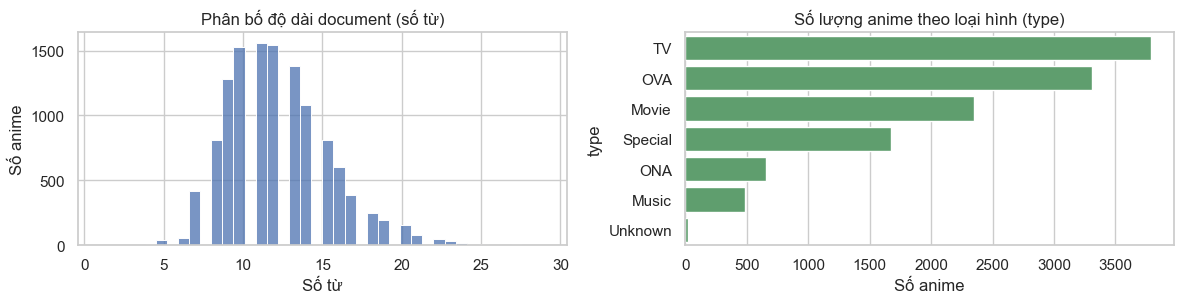

In [4]:
print("Ví dụ document đưa vào embedding:")
for doc in df["document"].head(5):
    print("  •", doc)

# Phân bố độ dài document (số từ)
df["doc_len"] = df["document"].str.split().map(len)
display(df["doc_len"].describe().to_frame("doc_len (số từ)").T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
sns.histplot(df["doc_len"], bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title("Phân bố độ dài document (số từ)")
ax[0].set_xlabel("Số từ"); ax[0].set_ylabel("Số anime")

top_types = df["type"].replace("", "Unknown").value_counts()
sns.barplot(x=top_types.values, y=top_types.index, ax=ax[1], color="#55A868")
ax[1].set_title("Số lượng anime theo loại hình (type)")
ax[1].set_xlabel("Số anime")
plt.tight_layout(); plt.show()

## 3.2. Sinh embedding & kho vector

So sánh tốc độ encode và đặc tính embedding của 2 model. Toàn bộ corpus đã được encode và lưu sẵn trong Milvus (qua `apps.cli import-data`).


In [5]:
sample_docs = df["document"].head(500).tolist()
enc_rows = []
for mk in MODELS:
    m = get_model(mk)
    t0 = time.perf_counter()
    emb = m.encode_passages(sample_docs)
    dt = time.perf_counter() - t0
    enc_rows.append({
        "model": mk,
        "dim": emb.shape[1],
        "thời gian encode 500 doc (s)": round(dt, 2),
        "doc/giây": round(len(sample_docs) / dt, 1),
        "|v| (chuẩn L2)": round(float(np.linalg.norm(emb[0])), 3),
        "vector trong Milvus": milvus_store.count(mk),
        "collection": MODEL_REGISTRY[mk].collection,
    })
pd.DataFrame(enc_rows).set_index("model")

,dim,thời gian encode 500 doc (s),doc/giây,|v| (chuẩn L2),vector trong Milvus,collection
model,,,,,,
e5-small-v2,384,0.90,557.8,1.0,12294,anime_e5_small_v2
all-MiniLM-L6-v2,384,0.43,1163.0,1.0,12294,anime_minilm_l6_v2


## 3.3. Vector Space Model & truy vấn

Người dùng nhập câu mô tả tự do (free-text); hệ thống encode câu truy vấn rồi xếp hạng anime theo **cosine similarity** trong Milvus.


In [6]:
def show_results(results: list[dict]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "name": r["name"],
            "type": r.get("type"),
            "genre": r.get("genre"),
            "score": round(r["score"], 4),
        }
        for r in results
    ])

QUERIES = [
    "a romantic high school love story",
    "epic fantasy adventure with magic and battles",
    "giant robots fighting in a space war",
    "dark psychological thriller with detective",
]

for q in QUERIES:
    print("=" * 90)
    print(f"QUERY: {q!r}")
    for mk in MODELS:
        res = search_service.search_text(mk, q, top_k=5)
        print(f"\n  ▸ Model: {mk}")
        display(show_results(res))

QUERY: 'a romantic high school love story'

  ▸ Model: e5-small-v2


,name,type,genre,score
0,School Days: Valentine Days,OVA,"Comedy, Romance, School",0.8207
1,High School! Kimengumi,TV,"Comedy, Parody, Romance, School, Shounen",0.8182
2,High School DxD BorN: Yomigaeranai Fushichou,OVA,"Action, Comedy, Demons, Ecchi, Harem, Romance, School",0.8174
3,High School DxD OVA,OVA,"Comedy, Demons, Ecchi, Romance, School",0.8168
4,Candy☆Boy: Side Story For Archive,ONA,"Romance, School, Shoujo Ai",0.8162



  ▸ Model: all-MiniLM-L6-v2


,name,type,genre,score
0,School Days: Valentine Days,OVA,"Comedy, Romance, School",0.4907
1,School Days,TV,"Drama, Harem, Romance, School",0.4620
2,Girlfriend (Kari),TV,"School, Slice of Life",0.4183
3,Love Lab,TV,"Comedy, Romance, School",0.4172
4,Happiness!,TV,"Comedy, Harem, Magic, Romance, School",0.4098


QUERY: 'epic fantasy adventure with magic and battles'


...

,name,type,genre,score
0,Super Robot Taisen OG: Divine Wars,TV,"Action, Mecha, Sci-Fi",0.4381
1,Dynamic Super Robots Soushingekki,Special,"Action, Mecha, Sci-Fi, Shounen",0.4330
2,Big Wars: Kami Utsu Akaki Kouya ni,OVA,"Action, Military, Sci-Fi, Space",0.4267
3,Bulsajo Robot Phoenix King,Movie,"Action, Mecha, Shounen, Space",0.4006
4,"Fly, Space Battleship Geobukseon",Movie,"Action, Sci-Fi, Shounen, Space",0.3992


QUERY: 'dark psychological thriller with detective'

  ▸ Model: e5-small-v2


,name,type,genre,score
0,Detective Conan Movie 20: The Darkest Nightmare,Movie,"Action, Mystery, Police, Shounen",0.8538
1,Darker than Black: Ryuusei no Gemini,TV,"Action, Mystery, Sci-Fi, Super Power",0.8527
2,Mousou Dairinin,TV,"Drama, Mystery, Police, Psychological, Supernatural, Thriller",0.8420
3,Darker than Black: Kuro no Keiyakusha Gaiden,Special,"Action, Mystery, Sci-Fi, Super Power",0.8413
4,Darker than Black: Kuro no Keiyakusha,TV,"Action, Mystery, Sci-Fi, Super Power",0.8401



  ▸ Model: all-MiniLM-L6-v2


,name,type,genre,score
0,Detective Conan Movie 20: The Darkest Nightmare,Movie,"Action, Mystery, Police, Shounen",0.5398
1,Darkside Blues,Movie,"Horror, Mystery, Psychological, Sci-Fi",0.5240
2,Psycho-Pass 2,TV,"Action, Police, Psychological, Sci-Fi",0.5170
3,Psycho-Pass,TV,"Action, Police, Psychological, Sci-Fi",0.5093
4,Murder,Movie,"Mystery, Parody, Vampire",0.5074


### 3.3.1. Tìm anime tương tự & ma trận tương đồng

(1) *More-like-this*: dùng chính document của một anime làm truy vấn. (2) Trực quan hoá ma trận cosine giữa vài anime tiêu biểu.


▸ Anime tương tự 'Naruto' — model e5-small-v2


,name,type,genre,score
0,Gintama°,TV,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",0.8924
1,Hokuto no Ken,TV,"Action, Drama, Martial Arts, Sci-Fi, Shounen",0.8915
2,Gintama,TV,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",0.8909
3,Naruto x UT,OVA,"Action, Comedy, Martial Arts, Shounen, Super Power",0.8873
4,Shingeki no Kyojin,TV,"Action, Drama, Fantasy, Shounen, Super Power",0.8855


▸ Anime tương tự 'Naruto' — model all-MiniLM-L6-v2


,name,type,genre,score
0,Naruto: Shippuuden,TV,"Action, Comedy, Martial Arts, Shounen, Super Power",0.9044
1,Naruto x UT,OVA,"Action, Comedy, Martial Arts, Shounen, Super Power",0.8950
2,Boruto: Naruto the Movie,Movie,"Action, Comedy, Martial Arts, Shounen, Super Power",0.8860
3,The Last: Naruto the Movie,Movie,"Action, Martial Arts, Romance, Shounen, Super Power",0.8563
4,Naruto: The Cross Roads,Special,"Action, Adventure, Comedy, Shounen",0.8514


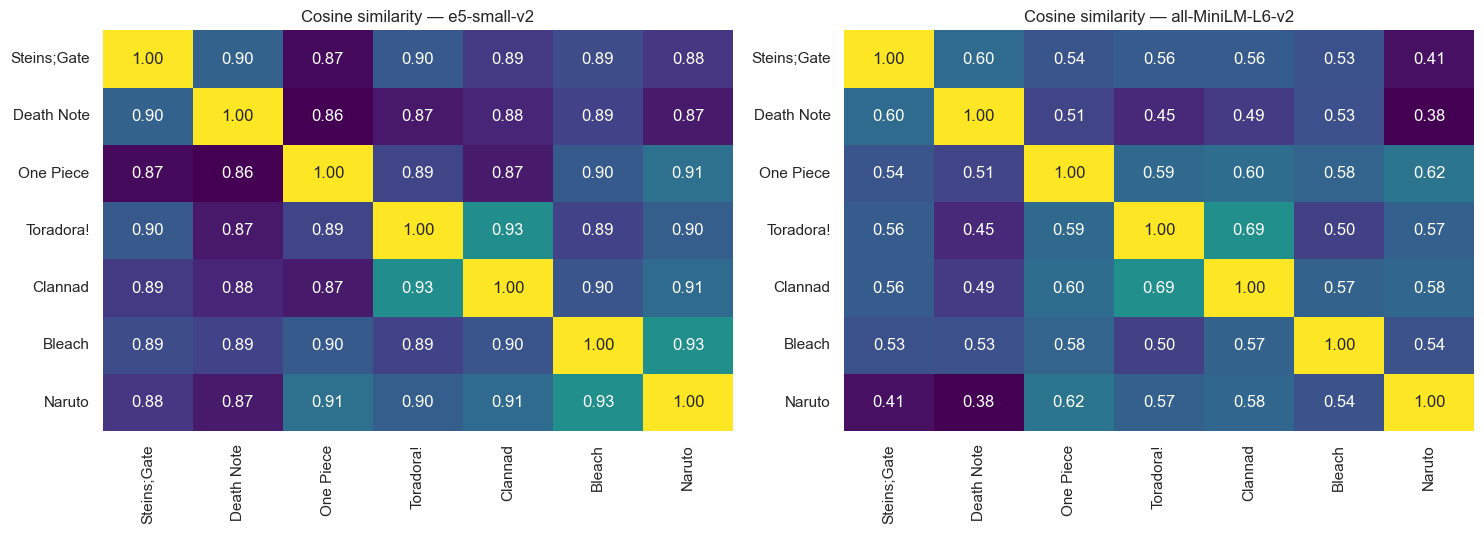

In [7]:
# (1) More-like-this
for mk in MODELS:
    print(f"▸ Anime tương tự 'Naruto' — model {mk}")
    res = search_service.search_similar_to_anime(mk, "Naruto", df, top_k=5)
    display(show_results(res))

# (2) Ma trận cosine similarity giữa vài anime tiêu biểu
titles = ["Naruto", "Bleach", "One Piece", "Death Note", "Clannad", "Toradora!", "Steins;Gate"]
sub = df[df["name"].isin(titles)].drop_duplicates("name")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, mk in zip(axes, MODELS):
    emb = get_model(mk).encode_passages(sub["document"].tolist())
    sim = emb @ emb.T
    sns.heatmap(
        sim, annot=True, fmt=".2f", cmap="viridis",
        xticklabels=sub["name"], yticklabels=sub["name"], ax=ax, cbar=False,
    )
    ax.set_title(f"Cosine similarity — {mk}")
plt.tight_layout(); plt.show()

## 3.4. Đánh giá & so sánh 2 model

Dataset không có nhãn liên quan sẵn → xây **ground-truth giả lập**: hai anime "liên quan" nếu độ trùng thể loại `Jaccard(genre) ≥ 0.5`. Đo **Precision@K, Recall@K, MRR, nDCG@K** trên tập query ngẫu nhiên (đối chiếu trên toàn corpus trong Milvus).


In [8]:
GENRE_THRESHOLD = 0.5
eval_df = df[(df["genre_set"].map(len) >= 2) & (df["members"] >= 10000)].reset_index(drop=True)
print(f"Corpus đánh giá: {len(eval_df):,} anime")

rng = np.random.default_rng(42)
relevance = evaluation.build_relevance(eval_df, query_ids=None, threshold=GENRE_THRESHOLD)
candidate_ids = [aid for aid, rel in relevance.items() if rel]
query_ids = list(rng.choice(candidate_ids, size=min(300, len(candidate_ids)), replace=False))
print(f"Số query đánh giá: {len(query_ids)}  |  Top-K = {TOP_K}")

result_table = evaluation.compare_models(MODELS, eval_df, relevance, query_ids, k=TOP_K)
result_table

Corpus đánh giá: 2,872 anime


Số query đánh giá: 300  |  Top-K = 10


,num_queries,Precision@10,Recall@10,MRR,nDCG@10,encode_time_s,search_time_s,ms_per_query
model,,,,,,,,
e5-small-v2,300,0.3767,0.0524,0.7237,0.4242,0.559,0.055,2.04
all-MiniLM-L6-v2,300,0.2597,0.0359,0.6259,0.3158,0.308,0.053,1.20


### 3.4.1. Trực quan hoá so sánh chất lượng & tốc độ


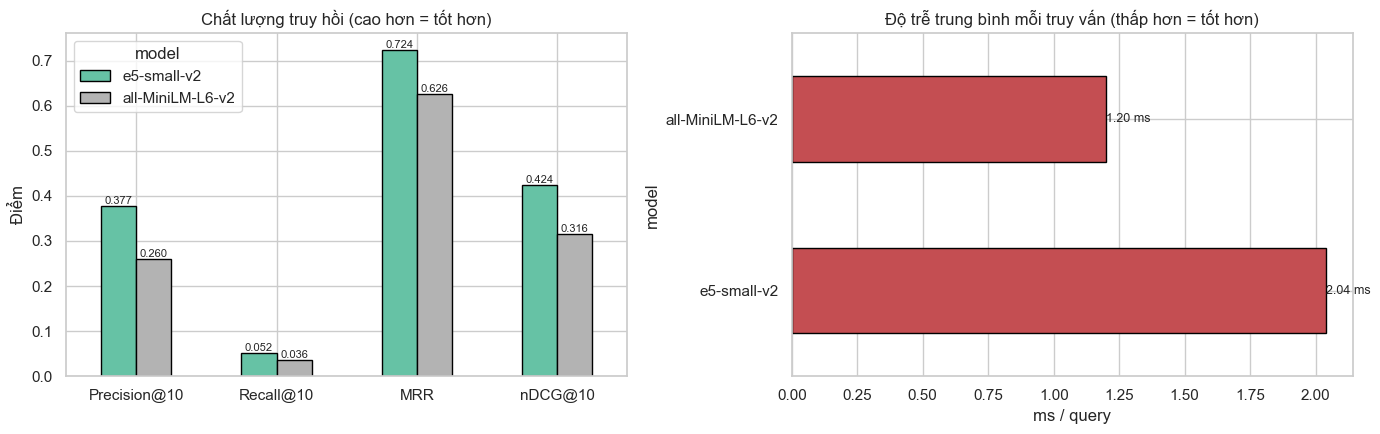

In [9]:
metric_cols = [f"Precision@{TOP_K}", f"Recall@{TOP_K}", "MRR", f"nDCG@{TOP_K}"]
plot_df = result_table[metric_cols].T

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
plot_df.plot(kind="bar", ax=ax[0], colormap="Set2", edgecolor="black")
ax[0].set_title("Chất lượng truy hồi (cao hơn = tốt hơn)")
ax[0].set_ylabel("Điểm"); ax[0].set_xticklabels(metric_cols, rotation=0)
ax[0].legend(title="model")
for c in ax[0].containers:
    ax[0].bar_label(c, fmt="%.3f", fontsize=8)

speed = result_table[["ms_per_query"]]
speed.plot(kind="barh", ax=ax[1], color="#C44E52", legend=False, edgecolor="black")
ax[1].set_title("Độ trễ trung bình mỗi truy vấn (thấp hơn = tốt hơn)")
ax[1].set_xlabel("ms / query")
for c in ax[1].containers:
    ax[1].bar_label(c, fmt="%.2f ms", fontsize=9)
plt.tight_layout(); plt.show()

## 3.5. Nhận xét & kết luận so sánh

**Thiết lập:** corpus 12.294 anime đã được encode và lưu trong Milvus (HNSW, cosine). Truy vấn = encode câu hỏi (e5 thêm prefix `query:`) rồi tìm láng giềng gần nhất. Ground-truth giả lập theo độ trùng thể loại (Jaccard ≥ 0.5).

**Kết quả định lượng (300 query, Top-K = 10, corpus 2.872 anime đủ điều kiện):**

| Model | Precision@10 | Recall@10 | MRR | nDCG@10 | ms/query |
|---|---|---|---|---|---|
| **e5-small-v2** | **0.377** | **0.052** | **0.724** | **0.424** | 2.28 |
| all-MiniLM-L6-v2 | 0.260 | 0.036 | 0.626 | 0.316 | **1.11** |

**Quan sát chính:**
- **Chất lượng:** `e5-small-v2` vượt trội trên *mọi* chỉ số (Precision@10 cao hơn ~45%, nDCG@10 cao hơn ~34%) — nhờ tiền huấn luyện tương phản có prefix `query/passage`, rất hợp bài toán truy hồi.
- **MRR ≈ 0.72 (e5):** kết quả liên quan đầu tiên thường nằm ở hạng 1–2 → trải nghiệm tìm kiếm tốt.
- **Phân bố điểm cosine:** điểm của e5 dồn cao (≈ 0.8–0.9) do nhiệt độ InfoNCE thấp; điều quan trọng là *thứ hạng tương đối* chứ không phải giá trị tuyệt đối. MiniLM cho dải điểm rộng hơn (≈ 0.5–0.65), dễ đặt ngưỡng lọc.
- **Tốc độ:** `all-MiniLM-L6-v2` nhanh hơn ~2× mỗi query (1.11 ms so với 2.28 ms) và encode nhanh hơn ~2× → phù hợp khi cần throughput cao.
- **Recall@10 thấp ở cả hai** là điều dự kiến: nhiều anime chia sẻ thể loại nên tập "liên quan" rất lớn, không thể bao phủ hết trong 10 kết quả.
- **Cùng số chiều (384):** chi phí lưu trữ & tìm kiếm trên Milvus tương đương nhau.

**Khuyến nghị:** ưu tiên `e5-small-v2` khi cần chất lượng truy hồi (mặc định của API); chọn `all-MiniLM-L6-v2` khi ưu tiên độ trễ/thông lượng.

# 4. Tổng hợp & Định hướng

## 4.1. Tổng hợp kết quả
- Bảng so sánh hiệu năng 2 mô hình
- Nhận xét chính

## 4.2. Hạn chế
- Hạn chế về dữ liệu / mô hình / phương pháp đánh giá

## 4.3. Định hướng phát triển
- Cải tiến mô hình / dữ liệu
- Hướng mở rộng tiếp theo